In [10]:
import matplotlib.pyplot as plt
import numpy as np
# from astropy.time import Time
import pandas as pd
import os

In [11]:
# def julian_to_datetimes(julian_dates_array):
#     julian_dates_array = julian_dates_array[:, 0] + julian_dates_array[:, 1]
#     utc_times = Time(julian_dates_array, format='jd')
#     datetime_times_array = utc_times.to_datetime()
#     return datetime_times_array

In [12]:
def plot_epoch_data(epoch_times: np.ndarray, data: np.ndarray, amt_cols: int = 5, xlabel='Time', ylabel='Value', title='Epoch Data Plot'):
    """
    Plots data against epoch time.
    
    Parameters:
    - epoch_times: numpy array of epoch times (in seconds since Unix epoch).
    - data: numpy array of corresponding data points.
    - xlabel: label for the x-axis (default is 'Time').
    - ylabel: label for the y-axis (default is 'Value').
    - title: plot title (default is 'Epoch Data Plot').
    
    Returns:
    - None
    """
    # Convert epoch times to datetime objects for plotting
    # datetime_times = [datetime.datetime.fromtimestamp(ts[0]) for ts in epoch_times]
    
    times = julian_to_datetimes(epoch_times)
    
    print(len(times), len(data[:, 0]))

    # Create the plot
    plt.figure(figsize=(8, 6))
    for i in range(amt_cols):
        plt.plot(times, data[:, i], marker='o', linestyle='-', markersize=5)
    
    # Formatting the plot
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    
    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45)
    
    # Show the plot
    plt.tight_layout()
    plt.show()

In [14]:
def modtran_data_files(path: str) -> list:
    files = [path + "/" + file for file in os.listdir(path) if file.endswith(".tp7")]
    return files

In [19]:
def test_read_tp7(filename: str) -> np.ndarray:
    
    with open(filename, 'r') as file:
        lines = file.readlines()

    # Determine if the file represents a daytime or nighttime file based on the first line
    day_or_night = lines[0]
    size = 4000 if day_or_night[0] == 'F' else 4996

    # Determine number of columns based on the last line before data ends
    sample_row = lines[-2].split()
    num_cols = len(sample_row)
    num_runs = len([line for line in lines if line.strip() == lines[-1].strip()])
    print(num_runs)
    # Define starting index based on the number of columns detected
    start_index = 13 if num_cols == 12 else 12

    # Initialize an empty grid array with calculated dimensions
    grid = np.zeros((size, num_cols, num_runs))

    # Iterate through each run and populate the grid
    for i in range(num_runs):
        idxs = start_index + (i * ((size + 1) + start_index))
        run_lines = lines[idxs:idxs + size]
        grid[:, :, i] = np.genfromtxt(run_lines, dtype=float, usecols=None)
    
    return grid


In [20]:
def test_read_tp7_headers(filename: str) -> list:
    
    with open(filename, "r") as file:
        lines = file.readlines()
    
    # Determine if the file represents a daytime or nighttime file based on the first line
    day_or_night = lines[0]
    size = 4000 if day_or_night[0] == 'F' else 4996
    
    # Determine number of columns based on the last line before data ends
    sample_row = lines[-2].split()
    num_cols = len(sample_row)
    num_runs = len([line for line in lines if line.strip() == lines[-1].strip()])
    print(num_runs)

    # Define starting index based on the number of columns detected
    start_index = 13 if num_cols == 12 else 12
    
    #build empty list for headers
    lst = [['#' for col in range(start_index)] for row in range(num_runs)]
    #populate list
    for i in np.arange(0,num_runs,1):
        idxs = (i * ((size + 1) + start_index))
        idxl = idxs + start_index
        thing = lines[idxs:idxl]
        for j in range(start_index):
            lst[i][j] = thing[j]

    return lst

00, 41, 60, 75, 85

In [21]:
a00_files = modtran_data_files("../data/Modtran_Unfiltering_Tape7s_SZA00")
a41_files = modtran_data_files("../data/Modtran_Unfiltering_Tape7s_SZA41")
a60_files = modtran_data_files("../data/Modtran_Unfiltering_Tape7s_SZA60")
a75_files = modtran_data_files("../data/Modtran_Unfiltering_Tape7s_SZA75")
a85_files = modtran_data_files("../data/Modtran_Unfiltering_Tape7s_SZA85")

In [22]:
tp7_00 = [test_read_tp7(file) for file in a00_files]
tp7_41 = [test_read_tp7(file) for file in a41_files]

147
630
84
315
63
147
84
315
630
63


In [26]:
class Tape7:
    def __init__(self, filepath: str):
        self.filepath = filepath
        self.num_runs = 0
        self.header_data = self.read_tp7_headers(self.filepath)
        self.file_data = self.read_tp7(self.filepath)
        self.rads = []
        self.describer_df = None
        
    def read_tp7(self, filepath: str) -> np.ndarray:
    
        with open(filepath, 'r') as file:
            lines = file.readlines()
    
        # Determine if the file represents a daytime or nighttime file based on the first line
        day_or_night = lines[0]
        size = 4000 if day_or_night[0] == 'F' else 4996
    
        # Determine number of columns based on the last line before data ends
        sample_row = lines[-2].split()
        num_cols = len(sample_row)
        num_runs = len([line for line in lines if line.strip() == lines[-1].strip()])

        # Define starting index based on the number of columns detected
        start_index = 13 if num_cols == 12 else 12
    
        # Initialize an empty grid array with calculated dimensions
        grid = np.zeros((size, num_cols, num_runs))
    
        # Iterate through each run and populate the grid
        for i in range(num_runs):
            idxs = start_index + (i * ((size + 1) + start_index))
            run_lines = lines[idxs:idxs + size]
            grid[:, :, i] = np.genfromtxt(run_lines, dtype=float, usecols=None)
            
        self.file_data = grid
        return grid
    
    def read_tp7_headers(self, filepath: str) -> list:
    
        with open(filepath, "r") as file:
            lines = file.readlines()
    
        # Determine if the file represents a daytime or nighttime file based on the first line
        day_or_night = lines[0]
        size = 4000 if day_or_night[0] == 'F' else 4996
        
        # Determine number of columns based on the last line before data ends
        sample_row = lines[-2].split()
        num_cols = len(sample_row)
        num_runs = len([line for line in lines if line.strip() == lines[-1].strip()])
    
        # Define starting index based on the number of columns detected
        start_index = 13 if num_cols == 12 else 12
        
        #build empty list for headers
        lst = [['#' for col in range(start_index)] for row in range(num_runs)]
        #populate list
        for i in np.arange(0,num_runs,1):
            idxs = (i * ((size + 1) + start_index))
            idxl = idxs + start_index
            thing = lines[idxs:idxl]
            for j in range(start_index):
                lst[i][j] = thing[j]
                
        self.header_data = lst
        return lst
    
    def get_title(self, name: str) -> str:
        file_name = name.split('/')[-1]
        scene_type = file_name.split('_')[0]

        file_to_title = {
            "lnd": "Land",
            "ocecld": "Cloudy Ocean",
            "oceclr": "Clear Ocean",
            "sno": "Snow",
            "dc": "Deep Convective Cloud"
        }
        title = file_to_title.get(scene_type, -1)

        if title == -1:
            raise ValueError("File not found")
        return title
    
    def build_scene_description(self):
        num_runs = self.num_runs = np.shape(self.file_data)[2]
        header_data = self.header_data

        # Initialize descriptor arrays
        scene, runnumber, sza, vza, raz = [], [], np.zeros(num_runs), np.zeros(num_runs), np.zeros(num_runs)
        cldtype, cldalt, cldthick, cldext = [], np.zeros(num_runs), np.zeros(num_runs), np.zeros(num_runs)
        surfacetemp, albedomodel, met, windspd = np.zeros(num_runs), np.zeros(num_runs), np.zeros(num_runs), np.zeros(num_runs)
        atmmodel, season, aerosoltype = [], [], []
        
        title = self.get_title(self.filepath)
        
        for i in range(num_runs):
            self.populate_scene_data(i, title, scene, runnumber, sza, vza, raz, header_data, cldtype,
                                     cldalt, cldthick, cldext, surfacetemp, albedomodel, met, windspd,
                                     atmmodel, season, aerosoltype)
        
        if title == "Land" or title == "Deep Convective Cloud":
            vza = 180 - vza
        df = self.create_description_dataframe(title, scene, sza, vza, raz, cldtype, cldalt, cldthick, cldext,surfacetemp, albedomodel, met, windspd, atmmodel, season, aerosoltype, runnumber)
        
        self.describer_df = df
        return self.describer_df
    
    def populate_scene_data(self, i, title, scene, runnumber, sza, vza, raz, headerdata, cldtype,
                            cldalt, cldthick, cldext, surfacetemp, albedomodel, met, windspd,
                            atmmodel, season, aerosoltype):
        
        scene.append(title)
        runnumber.append(i)
        
        if title == "Land":
            sza[i] = headerdata[i][10].split()[2]
            raz[i] = headerdata[i][10].split()[5]
            
            card3 = headerdata[i][5].split()
            if len(card3) != 7:
                thing1 = card3[2][:9]
                thing2 = card3[2][9:]
                card3.append(card3[5])
                card3[5] = card3[4]
                card3[4] = card3[3]
                card3[3] = thing2
                card3[2] = thing1
            vza[i] = card3[2]
            
            if headerdata[i][1].split()[4] == '0':
                ctype = 'No cloud'
                calt = 0
                cthick = 0
                cext = 0
            if headerdata[i][1].split()[4] == '18':
                if headerdata[i][2].split()[0] == '1.000':
                    ctype = 'ICLD 18: cirrus cloud'    
                    calt = 7
                    cthick = 1
                    cext = 4
                if headerdata[i][2].split()[0] == '2.000':
                    ctype = 'ICLD 18: cirrus cloud'     
                    calt = 7
                    cthick = 2
                    cext = 6    
            if headerdata[i][1].split()[4] == '3':
                ctype = 'ICLD 3: stratus cloud'
                calt = 0.5 
                cthick = 0.2
                cext = 28
            if headerdata[i][1].split()[4] == '1':
                ctype = 'ICLD 1: cumulus cloud'      
                calt = 0.66
                cthick = 2.34
                cext = 92.6
    
            cldtype.append(ctype)
            cldalt[i] = calt
            cldthick[i] = cthick
            cldext[i] = cext
            
            
            if headerdata[i][0].split()[1] == '1':
                atmmodel.append('Tropical')
            if headerdata[i][0].split()[1] == '2':
                atmmodel.append('Midlatitude Summer')
            if headerdata[i][0].split()[1] == '6':
                atmmodel.append('1976 US Standard')
            if headerdata[i][0].split()[1] == '3':
                atmmodel.append('Midlatitude Winter')
                
            if headerdata[i][1].split()[0] == '10':
                aerosoltype.append('Desert')
            if headerdata[i][1].split()[0] == '1':
                aerosoltype.append('Rural')   
                
            if headerdata[i][1].split()[1] == '1':
                season.append('Spring/Summer')
            if headerdata[i][1].split()[1] == '2':
                season.append('Fall/Winter')         
                
            surfacetemp[i] = headerdata[i][0].split()[14]
            albedomodel[i] = headerdata[i][0].split()[15]
            met[i] = headerdata[i][1].split()[6]
            windspd[i] = headerdata[i][1].split()[7]
            
        elif title == "Cloudy Ocean":
            
            sza[i] = headerdata[i][11].split()[0]
            vza[i] = headerdata[i][11].split()[1]
            raz[i] = headerdata[i][11].split()[2]
            
            if headerdata[i][1].split()[4] == '3':
                ctype = 'ICLD 3: stratus cloud'
                calt = 0.5 
                cthick = 0.2
                cext = 28
            if headerdata[i][1].split()[4] == '1':
                ctype = 'ICLD 1: cumulus cloud'      
                calt = 0.66
                cthick = 2.34
                cext = 92.6
            if headerdata[i][1].split()[4] == '18':
                if headerdata[i][2].split()[0] == '1.000':
                    ctype = 'ICLD 18: cirrus cloud'    
                    calt = 7
                    cthick = 1
                    cext = 4
                if headerdata[i][2].split()[0] == '2.000':
                    ctype = 'ICLD 18: cirrus cloud'     
                    calt = 7
                    cthick = 2
                    cext = 6
    
            cldtype.append(ctype)
            cldalt[i] = calt
            cldthick[i] = cthick
            cldext[i] = cext
            
        elif title == "Clear Ocean":
            sza[i] = headerdata[i][11].split()[0]
            vza[i] = headerdata[i][11].split()[1]
            raz[i] = headerdata[i][11].split()[2]
            met[i] = headerdata[i][1].split()[6]
            
        elif title == "Snow":
            sza[i] = headerdata[i][11].split()[0]
            vza[i] = headerdata[i][11].split()[1]
            raz[i] = headerdata[i][11].split()[2]
            surfacetemp[i] = headerdata[i][0].split()[14]
            albedomodel[i] = headerdata[i][0].split()[15]
    
            if headerdata[i][1].split()[4] == '0':
                ctype = 'No cloud'
                calt = 0
                cthick = 0
                cext = 0
            if headerdata[i][1].split()[4] == '19':
                ctype = 'ICLD 19: subvisual cirrus cloud'      
                calt = 10
                cthick = 0.3
                cext = 1
            if headerdata[i][1].split()[4] == '18':
                ctype = 'ICLD 18: cirrus cloud'    
                calt = 0.5
                cthick = 1
                cext = 2
            if headerdata[i][1].split()[4] == '3':
                ctype = 'ICLD 3: stratus cloud'
                calt = 0.1
                cthick = 3
                cext = 30
            if headerdata[i][1].split()[4] == '4':
                ctype = 'ICLD 4: strato-cumulus cloud'      
                calt = 0.1
                cthick = 0.4
                cext = 10
                
            cldtype.append(ctype)
            cldalt[i] = calt
            cldthick[i] = cthick
            cldext[i] = cext
            
        elif title == "Deep Convective Cloud":
            sza[i] = headerdata[i][10].split()[2]
            raz[i] = headerdata[i][10].split()[5]
            cldalt[i] = headerdata[i][2].split()[1]
            #deal with card 3 for vza
            card3 = headerdata[i][5].split()
            if len(card3) != 7:
                thing1 = card3[2][:9]
                thing2 = card3[2][9:]
                card3.append(card3[5])
                card3[5] = card3[4]
                card3[4] = card3[3]
                card3[3] = thing2
                card3[2] = thing1
            vza[i] = card3[2]
        
    def create_description_dataframe(self, title, scene, sza, vza, raz, cldtype, cldalt, cldthick, cldext,surfacetemp, albedomodel, met, windspd, atmmodel, season, aerosoltype, runnumber):
        
        data = None
        if title == "Land":
            data = {'Scene': scene, 'SZA': sza, 'VZA': vza, 'RAZ': raz, 'Atm model': atmmodel, 'Sfc Temp': surfacetemp, 'Albedo model': albedomodel, 'Season': season, 'Aerosol Type': aerosoltype, 'Met Range': met, 'Wind spd (ms-1)': windspd, 'Cld Type': cldtype, 'Cld Alt (km)': cldalt, "Cld Thick (km)": cldthick, 'Cld Ext Coef (km-1)': cldext, 'Run #': runnumber}
        elif title == "Cloudy Ocean":
            data = {'Scene': scene, 'SZA': sza, 'VZA': vza, 'RAZ': raz, 'Cld Type': cldtype, 'Cld Alt (km)': cldalt, "Cld Thick (km)": cldthick, 'Cld Ext Coef (km-1)': cldext, 'Run #': runnumber}
        elif title == "Clear Ocean":
            data = {'Scene': scene, 'SZA': sza, 'VZA': vza, 'RAZ': raz, 'Met Range': met, 'Run #': runnumber}
        elif title == "Snow":
            data = {'Scene': scene, 'SZA': sza, 'VZA': vza, 'RAZ': raz, 'Sfc Temp': surfacetemp, 'Albedo model': albedomodel, 'Cld Type': cldtype, 'Cld Alt (km)': cldalt, "Cld Thick (km)": cldthick, 'Cld Ext Coef (km-1)': cldext, 'Run #': runnumber}
        elif title == "Deep Convective Cloud":
            data = {'Scene': scene, 'SZA': sza, 'VZA': vza, 'RAZ': raz, 'Cloud Alt (km)': cldalt, 'Run #': runnumber}
        
        return pd.DataFrame(data)
    
    def compute_radiences(self):
        num_runs = self.num_runs
        tp7data = self.file_data
        colnums = self.get_column_numbers(tp7data)

        # Create the radiance array
        self.rads = np.zeros((4000, 3, num_runs))

        for i in range(num_runs):
            freq, refl, emit = self.calculate_radiances_for_run(i, tp7data, colnums)
            lam = (1 / freq) * 1E4
            swrad = (freq ** 2) * refl
            lwrad = (freq ** 2) * emit

            self.rads[:, 0, i] = lam
            self.rads[:, 1, i] = swrad
            self.rads[:, 2, i] = lwrad
        
        return self.rads
    
    def get_column_numbers(self, tp7data):
        """
        Determine column numbers based on the shape of tp7data.
        """
        if tp7data.shape[1] == 12:
            return [1, 6, 10, 5, 4]
        elif tp7data.shape[1] == 14:
            return [0, 7, 13, 5, 9]
        else:
            raise ValueError("Error with tp7data: Unexpected number of columns")
        
    def calculate_radiances_for_run(self, run_index, tp7data, colnums):
        """
        Calculate frequencies and radiances for a single run.
        """
        freq = tp7data[:, int(colnums[0]), run_index]
        tot = tp7data[:, int(colnums[4]), run_index]
        sfctot = tp7data[:, int(colnums[1]), run_index]
        thmsfcref = tp7data[:, int(colnums[2]), run_index]
        pathscat = tp7data[:, int(colnums[3]), run_index]
        refl = pathscat + sfctot - thmsfcref
        emit = tot - refl

        return freq, refl, emit      

In [27]:
a41_files

['./data/Modtran_Unfiltering_Tape7s_SZA41/oceclr_sz41L.tp7',
 './data/Modtran_Unfiltering_Tape7s_SZA41/ocecld_sz41L.tp7',
 './data/Modtran_Unfiltering_Tape7s_SZA41/sno_sz41L.tp7',
 './data/Modtran_Unfiltering_Tape7s_SZA41/lnd_sz41L.tp7',
 './data/Modtran_Unfiltering_Tape7s_SZA41/dc_sz41.spectra.tp7']

In [28]:
a41_dc = Tape7(a41_files[-1])

In [30]:
truth_dc_data = test_read_tp7(a41_files[-1])
truth_dc_headers = test_read_tp7_headers(a41_files[-1])

63
63


In [31]:
new_df = a41_dc.build_scene_description()

In [32]:
new_df

,Scene,SZA,VZA,RAZ,Cloud Alt (km),Run #
0,Deep Convective Cloud,41.400,0.00000,0.0,10.0,0
1,Deep Convective Cloud,41.400,0.00000,0.0,9.0,1
2,Deep Convective Cloud,41.400,0.00000,0.0,8.0,2
3,Deep Convective Cloud,41.905,29.49001,7.5,10.0,3
4,Deep Convective Cloud,41.905,29.49001,7.5,9.0,4
...,...,...,...,...,...,...
58,Deep Convective Cloud,33.398,79.91400,142.5,9.0,58
59,Deep Convective Cloud,33.398,79.91400,142.5,8.0,59
60,Deep Convective Cloud,31.400,79.91400,172.5,10.0,60
61,Deep Convective Cloud,31.400,79.91400,172.5,9.0,61


In [33]:
d_df

,Scene,SZA,VZA,RAZ,Cloud Alt (km),Run #
0,Deep Convective Cloud,41.400,0.00000,0.0,10.0,0
1,Deep Convective Cloud,41.400,0.00000,0.0,9.0,1
2,Deep Convective Cloud,41.400,0.00000,0.0,8.0,2
3,Deep Convective Cloud,41.905,29.49001,7.5,10.0,3
4,Deep Convective Cloud,41.905,29.49001,7.5,9.0,4
...,...,...,...,...,...,...
58,Deep Convective Cloud,33.398,79.91400,142.5,9.0,58
59,Deep Convective Cloud,33.398,79.91400,142.5,8.0,59
60,Deep Convective Cloud,31.400,79.91400,172.5,10.0,60
61,Deep Convective Cloud,31.400,79.91400,172.5,9.0,61


In [34]:
new_df.equals(d_df)

True

In [38]:
a41_dc.file_data is truth_dc_data, a41_dc.file_data is script_data 

(False, False)

63
sza [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


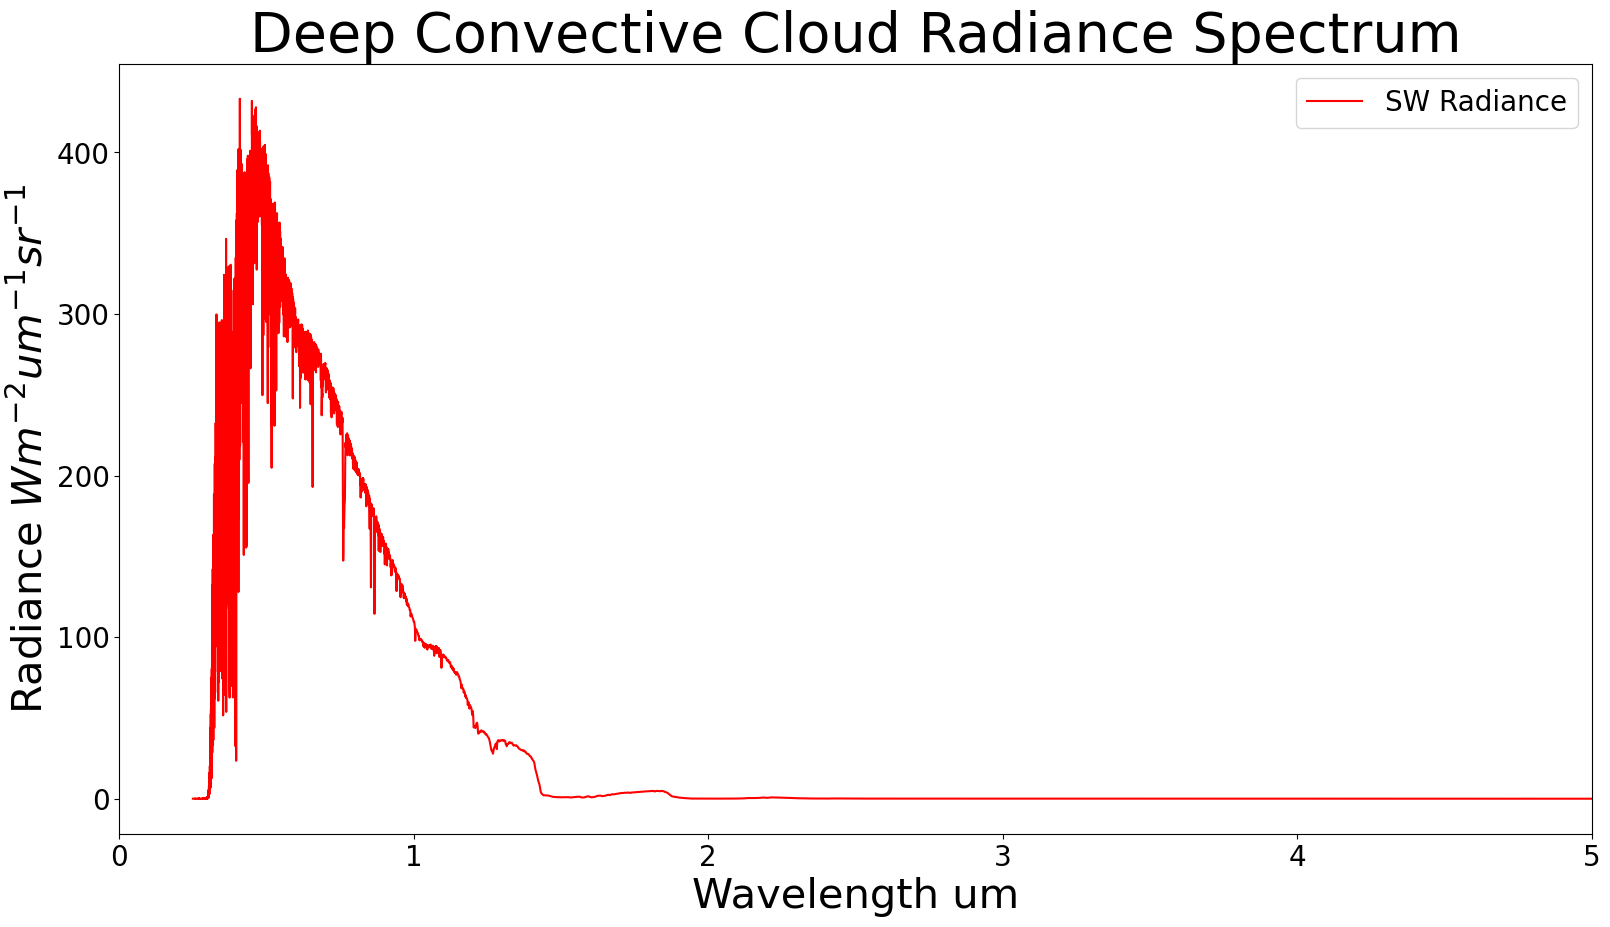

In [39]:
%run tp7/fergus_code/spectra+describer.py